In [2]:
import torch.nn as nn

In [68]:
class ContractionNetwork(nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.conv1=nn.Conv2d(in_channels, in_channels*2, kernel_size=3, padding=1)
    self.relu1=nn.ReLU(inplace=True)
    self.out_channels=in_channels*2
    self.conv2=nn.Conv2d(self.out_channels, self.out_channels, kernel_size=3, padding=1)
    self.relu2=nn.ReLU(inplace=True)
    self.max_pool=nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x=self.conv1(x)
    x=self.relu1(x)
    x=self.conv2(x)
    x=self.relu2(x)
    x_skip=x
    x=self.max_pool(x)
    return x, x_skip

In [69]:
class ExpansionNetwork(nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.upconv=nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
    self.concat_channels=in_channels
    self.conv1=nn.Conv2d(self.concat_channels, in_channels//2, kernel_size=3, padding=1)
    self.relu1=nn.ReLU(inplace=True)
    self.conv2=nn.Conv2d(in_channels//2, in_channels//2, kernel_size=3, padding=1)
    self.relu2=nn.ReLU(inplace=True)
  def forward(self, x, x_skip):
    x=self.upconv(x)
    x=torch.cat([x, x_skip], dim=1)
    x=self.conv1(x)
    x=self.relu1(x)
    x=self.conv2(x)
    x=self.relu2(x)
    return x


In [70]:
class ConcatenationPath(nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.contraction_first=ContractionNetwork(in_channels)
    self.contraction_second=ContractionNetwork(in_channels*2)
    self.contraction_third=ContractionNetwork(in_channels*4)
    self.contraction_fourth=ContractionNetwork(in_channels*8)
  def forward(self, x):
    skips=[]
    x, x_skip1=self.contraction_first(x)
    x, x_skip2=self.contraction_second(x)
    x, x_skip3=self.contraction_third(x)
    x, x_skip4=self.contraction_fourth(x)
    skips.append(x_skip1)
    skips.append(x_skip2)
    skips.append(x_skip3)
    skips.append(x_skip4)
    return x, skips

In [52]:
class ExpansivePath(nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.expansion_first=ExpansionNetwork(in_channels)
    self.expansion_second=ExpansionNetwork(in_channels//2)
    self.expansion_third=ExpansionNetwork(in_channels//4)
    self.expansion_fourth=ExpansionNetwork(in_channels//8)
  def forward(self, x, skips):
    x=self.expansion_first(x, skips[3])
    x=self.expansion_second(x, skips[2])
    x=self.expansion_third(x, skips[1])
    x=self.expansion_fourth(x, skips[0])
    return x


In [71]:
class UNET(nn.Module):
  def __init__(self, in_channels, num_classes):
    super().__init__()
    self.contraction=ConcatenationPath(in_channels)

    self.bottleneck_conv1=nn.Conv2d(in_channels*16, in_channels*32, kernel_size=3, padding=1)
    self.bottleneck_relu1=nn.ReLU(inplace=True)
    self.bottleneck_conv2=nn.Conv2d(in_channels*32, in_channels*32, kernel_size=3, padding=1)
    self.bottleneck_relu2=nn.ReLU(inplace=True)

    self.expansion=ExpansivePath(in_channels*32)
    self.classification_conv=nn.Conv2d(in_channels*2, num_classes, kernel_size=1)

  def forward(self, x):
    x, skips=self.contraction(x)
    x=self.bottleneck_conv1(x)
    x=self.bottleneck_relu1(x)
    x=self.bottleneck_conv2(x)
    x=self.bottleneck_relu2(x)

    x=self.expansion(x, skips)
    x=self.classification_conv(x)
    return x

In [72]:
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import random

class JointTransform:
    """Applies identical spatial transforms to both image and mask."""
    def __call__(self, image, mask):
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)
        if random.random() > 0.3:
            image = TF.vflip(image)
            mask = TF.vflip(mask)
        return image, mask

class OxfordPetWithAugmentation(datasets.OxfordIIITPet):
    def __init__(self, joint_transform=None, **kwargs):
        super().__init__(**kwargs)
        self.joint_transform = joint_transform

    def __getitem__(self, idx):
        image, mask = super().__getitem__(idx)
        if self.joint_transform:
            image, mask = self.joint_transform(image, mask)
        return image, mask

resize = transforms.Resize((256, 256))
mask_resize = transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST)

image_transform = transforms.Compose([
    resize,
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_transform = transforms.Compose([
    mask_resize,
    transforms.PILToTensor(),
])

val_image_transform = transforms.Compose([
    resize,
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = OxfordPetWithAugmentation(
    joint_transform=JointTransform(),
    root='./data', split='trainval', target_types='segmentation', download=True,
    transform=image_transform,
    target_transform=mask_transform,
)

val_dataset = datasets.OxfordIIITPet(
    root='./data', split='test', target_types='segmentation', download=True,
    transform=val_image_transform,
    target_transform=mask_transform,
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

In [73]:
criterion = nn.BCEWithLogitsLoss()
import torch
def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

def combined_loss(pred, target):
    return criterion(pred, target) + dice_loss(pred, target)



def iou(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return intersection / union

In [74]:
epoch_amount=150
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNET(3, 1).to(device)

batch_size=16
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
for epoch in range(epoch_amount):
    model.train()
    total_loss = 0
    for batch, mask in train_loader:
        batch, mask = batch.to(device), mask.to(device)
        mask = ((mask == 1) | (mask == 3)).float()

        optimizer.zero_grad()
        prediction = model(batch)
        loss = combined_loss(prediction, mask)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch} | Loss: {avg_loss:.4f}")

    model.eval()
    total_iou = 0
    with torch.no_grad():
        for batch, mask in val_loader:
            batch, mask = batch.to(device), mask.to(device)
            mask = ((mask == 1) | (mask == 3)).float()

            prediction = model(batch)
            total_iou += iou(prediction, mask).item()
    avg_iou = total_iou / len(val_loader)
    print(f"Epoch {epoch} | IoU: {avg_iou:.4f}")
    scheduler.step(avg_loss)

Epoch 0 | Loss: 1.2490
Epoch 0 | IoU: 0.2890
Epoch 1 | Loss: 1.0770
Epoch 1 | IoU: 0.5247
Epoch 2 | Loss: 0.9637
Epoch 2 | IoU: 0.5193
Epoch 3 | Loss: 0.9450
Epoch 3 | IoU: 0.5118
Epoch 4 | Loss: 0.9375
Epoch 4 | IoU: 0.5242
Epoch 5 | Loss: 0.9253
Epoch 5 | IoU: 0.5342
Epoch 6 | Loss: 0.8955
Epoch 6 | IoU: 0.5579
Epoch 7 | Loss: 0.8427
Epoch 7 | IoU: 0.5903
Epoch 8 | Loss: 0.8084
Epoch 8 | IoU: 0.6072
Epoch 9 | Loss: 0.7804
Epoch 9 | IoU: 0.6185
Epoch 10 | Loss: 0.7704
Epoch 10 | IoU: 0.6129
Epoch 11 | Loss: 0.7544
Epoch 11 | IoU: 0.6233
Epoch 12 | Loss: 0.7472
Epoch 12 | IoU: 0.6353
Epoch 13 | Loss: 0.7409
Epoch 13 | IoU: 0.6333
Epoch 14 | Loss: 0.7292
Epoch 14 | IoU: 0.6348
Epoch 15 | Loss: 0.7148
Epoch 15 | IoU: 0.6440
Epoch 16 | Loss: 0.7097
Epoch 16 | IoU: 0.6259
Epoch 17 | Loss: 0.6990
Epoch 17 | IoU: 0.6466
Epoch 18 | Loss: 0.6900
Epoch 18 | IoU: 0.6386
Epoch 19 | Loss: 0.6777
Epoch 19 | IoU: 0.6432
Epoch 20 | Loss: 0.6756
Epoch 20 | IoU: 0.6299
Epoch 21 | Loss: 0.6713
Epoch 21 

In [75]:
def predict(model, image, device, threshold=0.5):
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        output = model(image)
        pred = (torch.sigmoid(output) > threshold).float()
    return pred.squeeze(0)  # [1, H, W]

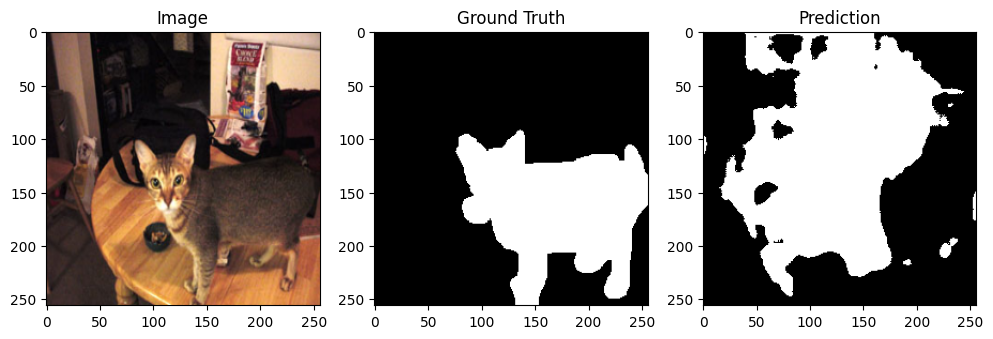

In [76]:
img, mask = val_dataset[0]
pred = predict(model, img, device='cuda')

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_display = (img * std + mean).clamp(0, 1)

binary_mask = ((mask == 1) | (mask == 3)).float()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_display.permute(1, 2, 0))
axes[0].set_title('Image')
axes[1].imshow(binary_mask.squeeze(0), cmap='gray')  # squeeze (1,H,W) -> (H,W)
axes[1].set_title('Ground Truth')
axes[2].imshow(pred.squeeze(0).cpu(), cmap='gray')   # squeeze (1,H,W) -> (H,W)
axes[2].set_title('Prediction')
plt.show()